# Baseline model: predict `risk_proxy`

Follow-up to [risk-proxy.ipynb](../analysis/risk-proxy.ipynb) 

**Target**: `risk_proxy` (normalized length × phase weight).

**Feature leakage note**: Do **not** include `Normalized_Length` or `PHASE_WEIGHT` as inputs—they define `risk_proxy`. We use `Shape__Length`, fiscal year, phase description, and a **reduced** work-mix name.


## 1. Load modeling dataset

Prefer `construction_with_risk_proxy.csv` produced by the EDA notebook (same path resolution as that notebook).


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split


csv_path = Path("../../src/data/processed/construction_with_risk_proxy.csv")
construction_df = pd.read_csv(csv_path)
print(f"Loaded rows={len(construction_df):,} from {csv_path.resolve()}")


Loaded rows=6,942 from /home/trevor/repos/CAP_3764_2026_Spring_Team_1/src/data/processed/construction_with_risk_proxy.csv


## 2. Modeling frame (copy)

Start from the construction table; keep only columns needed for training.


In [16]:
df_model = construction_df.copy()
df_model["WPWKMIXN"] = df_model["WPWKMIXN"].astype(str).str.strip()


## 3. Reduce work-mix categories 

Many rare `WPWKMIXN` values inflate the dummy space. Keep the top *k* by frequency and map the rest to `"Other"`.


In [17]:
TOP_K_WORK_MIX = 12
vc = df_model["WPWKMIXN"].value_counts()
top = set(vc.head(TOP_K_WORK_MIX).index)
df_model["work_mix_reduced"] = np.where(
    df_model["WPWKMIXN"].isin(top),
    df_model["WPWKMIXN"],
    "Other",
)
print("Reduced work-mix cardinality:", df_model["work_mix_reduced"].nunique())
print(df_model["work_mix_reduced"].value_counts().head(15))


Reduced work-mix cardinality: 13
work_mix_reduced
RESURFACING             1833
Other                   1125
ADD LANES & RECONSTR     882
BRIDGE-REPLACE AND A     638
INTERCHANGE RAMP (NE     585
ITS FREEWAY MANAGEME     476
RIGID PAVEMENT RECON     286
RIGID PAVEMENT REHAB     286
INTERSECTION IMPROVE     250
PEDESTRIAN SAFETY IM     158
FLEXIBLE PAVEMENT RE     148
INTERCHANGE - ADD LA     140
BIKE PATH/TRAIL          135
Name: count, dtype: int64


## 4. Feature matrix and target

Numeric + one-hot categoricals 


In [19]:
y = df_model["risk_proxy"]
num = df_model[["FISCALYR", "Shape__Length"]].copy()
# `drop_first=True` reduces perfect collinearity from the intercept
# 1-hot encoding for categoricals ("WPPHAZTP_DESC", "work_mix_reduced")
cat = pd.get_dummies(
    df_model[["WPPHAZTP_DESC", "work_mix_reduced"]],
    columns=["WPPHAZTP_DESC", "work_mix_reduced"],
    drop_first=True,
    dtype=float,
)
X = pd.concat([num, cat], axis=1)
# Print the first 5 rows of the feature matrix
print("Feature shape:", X.shape)
X.head()


Feature shape: (6942, 17)


,FISCALYR,Shape__Length,WPPHAZTP_DESC_Construction Completed,WPPHAZTP_DESC_Contract Executed,WPPHAZTP_DESC_Pre-Construction,work_mix_reduced_BIKE PATH/TRAIL,work_mix_reduced_BRIDGE-REPLACE AND A,work_mix_reduced_FLEXIBLE PAVEMENT RE,work_mix_reduced_INTERCHANGE - ADD LA,work_mix_reduced_INTERCHANGE RAMP (NE,work_mix_reduced_INTERSECTION IMPROVE,work_mix_reduced_ITS FREEWAY MANAGEME,work_mix_reduced_Other,work_mix_reduced_PEDESTRIAN SAFETY IM,work_mix_reduced_RESURFACING,work_mix_reduced_RIGID PAVEMENT RECON,work_mix_reduced_RIGID PAVEMENT REHAB
0,2025,115.922570,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023,279.354608,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,170.858574,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023,2177.798387,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,115.922570,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Train / test split  

Random forests handle mixed-scale numeric inputs and high-dimensional dummies without explicit scaling. 
- Baseline regressor for starter


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Test MSE:  {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R²:   {r2:.4f}")
print(f"Test MAE:  {mae:.6f}")
print(f"Test MAPE: {mape:.4f}")

Test MSE:  0.000027
Test RMSE: 0.005227
Test R²:   0.9967
Test MAE:  0.000365
Test MAPE: 0.0138


## 6. Quick interpretability: feature importances

Forest `feature_importances_` are not causal, but show which columns the tree splits use most often.


In [14]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(20)


Shape__Length                            9.061389e-01
WPPHAZTP_DESC_Construction Completed     7.266258e-02
WPPHAZTP_DESC_Pre-Construction           1.660936e-02
WPPHAZTP_DESC_Contract Executed          2.209253e-03
work_mix_reduced_Other                   9.332772e-04
FISCALYR                                 9.155732e-04
work_mix_reduced_RESURFACING             2.753790e-04
work_mix_reduced_PEDESTRIAN SAFETY IM    2.336074e-04
work_mix_reduced_BIKE PATH/TRAIL         2.043706e-05
work_mix_reduced_FLEXIBLE PAVEMENT RE    7.057419e-07
work_mix_reduced_INTERCHANGE RAMP (NE    3.919598e-07
work_mix_reduced_INTERSECTION IMPROVE    1.836022e-07
work_mix_reduced_RIGID PAVEMENT RECON    1.161618e-07
work_mix_reduced_ITS FREEWAY MANAGEME    1.025833e-07
work_mix_reduced_RIGID PAVEMENT REHAB    5.093879e-08
work_mix_reduced_BRIDGE-REPLACE AND A    4.695136e-08
work_mix_reduced_INTERCHANGE - ADD LA    7.520194e-09
dtype: float64

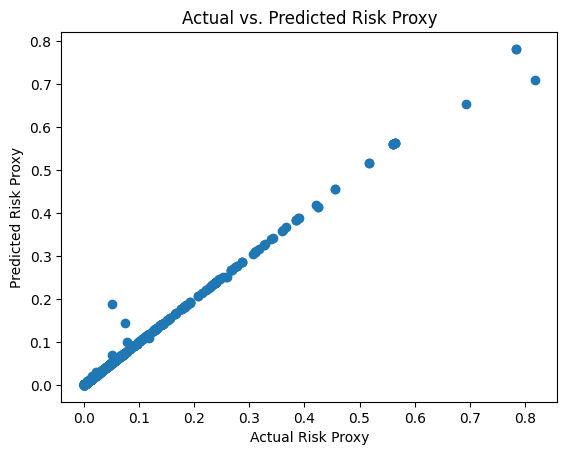

In [20]:
# Plot results
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Risk Proxy")
plt.ylabel("Predicted Risk Proxy")
plt.title("Actual vs. Predicted Risk Proxy")
plt.show()



## Modeling Limitatios & Leakage Insight
- The target variable `risk_proxy` is engineered directly from the input features `Normalized_Length` and `Phase_Weight`
- Even though these features were excluded from our inputs, their underlying components (`Shape_Length` and phase type categories) are still included
- The result ($R^2$ ~ .997) is near perfect accuracy due to indirect **data leakeage**

## Conclusion
- This baseline model, therefore, should be considered as an extension of our validation steps $\rightarrow$ *no predictive value*

### Next Steps
- Define an independent target variable (ex. project delay, cost overrun, or traffic impact)
- Introduce additional features (ex. spatial density or project overlap)
- Evaluate model performance under a **non-determinstic** target setup